In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from hmmlearn import hmm

In [2]:
states = ["Sunny", "Rainy"]
tran_matrix = np.array([[0.8, 0.2], 
                        [0.4, 0.6]])
print("\n Transition matrix:")
print(tran_matrix)


 Transition matrix:
[[0.8 0.2]
 [0.4 0.6]]


In [4]:
def simulate_markov_chain(start_state, n_steps=20):
    cur_state =     states.index(start_state)
    seq = [start_state]
    for _ in range(n_steps):
        cur_state = np.random.choice([0,1], p=tran_matrix[cur_state])
        seq.append(states[cur_state])
    return seq

mc_seq = simulate_markov_chain("Sunny", 15)
print("\n Generated Markov chain seq:")
print(mc_seq)



 Generated Markov chain seq:
['Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Rainy', 'Sunny', 'Rainy', 'Rainy']


In [5]:
hid_states = ["Hot", "Cold"]
observations = ["IceCream", "Coffee"]

model = hmm.MultinomialHMM(n_components=2, n_iter=50)
model.transmat_ = np.array([
    [0.7, 0.3],
    [0.4, 0.6]
])
model.emissionprob_ = np.array([
    [0.8, 0.2],
    [0.3, 0.7]
])
model.startprob_  =np.array([0.6, 0.4])
print("\n Transition matrix: \" Hidden states\" ")
print(model.transmat_)
print("\n Emission matrix")
print(model.emissionprob_)

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



 Transition matrix: " Hidden states" 
[[0.7 0.3]
 [0.4 0.6]]

 Emission matrix
[[0.8 0.2]
 [0.3 0.7]]


In [6]:
model.n_trials = 1
obs_seq, hidden_seq = model.sample(15)
obs_seq = obs_seq.flatten()
hidden_seq = hidden_seq.flatten()
decoded_obs = [observations[i] for i in obs_seq]
decoded_hidden = [hid_states[i] for i in hidden_seq]
print("\nGenerated Observations from HMM:")
print(decoded_obs)
print("\nActual Hidden States from HMM:")
print(decoded_hidden)


Generated Observations from HMM:
['IceCream', 'Coffee', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'IceCream', 'Coffee', 'IceCream', 'Coffee', 'IceCream', 'Coffee']

Actual Hidden States from HMM:
['Cold', 'Hot', 'Hot', 'Hot', 'Hot', 'Cold', 'Cold', 'Cold', 'Cold', 'Hot', 'Hot', 'Hot', 'Hot', 'Cold', 'Cold']


In [7]:
n_observations = len(observations)
X_decoded = np.zeros((len(obs_seq), n_observations))
X_decoded[np.arange(len(obs_seq)), obs_seq] =1

logprob,  pred_states = model.decode(X_decoded, algorithm="viterbi")
decoded_pred = [hidden_seq[i] for i in pred_states]
print("\n Pred Hidden states(Viterbi):")
print(decoded_pred)


 Pred Hidden states(Viterbi):
[np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0)]


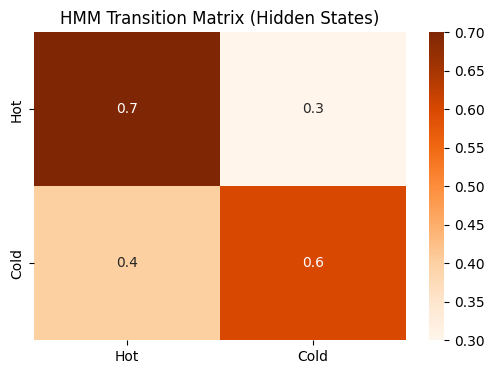

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(model.transmat_, annot=True, cmap="Oranges",
            xticklabels=hid_states, yticklabels=hid_states)
plt.title("HMM Transition Matrix (Hidden States)")
plt.show()

Most Likely Hidden States (Viterbi):
['Silence', 'Word1', 'Word2', 'Word2', 'Word3', 'Word3', 'Word3', 'Word3']


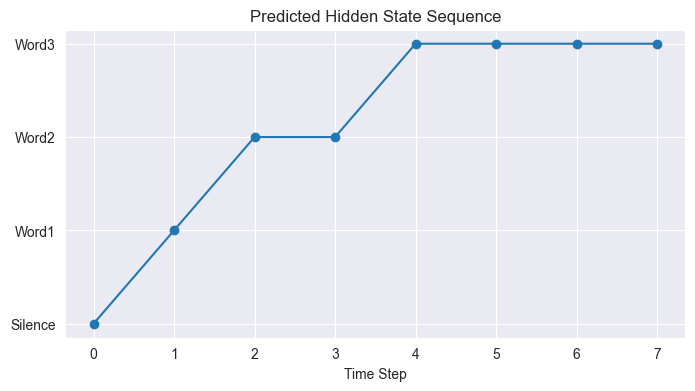

In [9]:
states = ["Silence", "Word1", "Word2", "Word3"]
n_states = len(states)
observations = ["Loud", "Soft"]
n_observations = len(observations)

start_probability = np.array([0.8, 0.1, 0.1, 0.0])
transition_probability = np.array([
    [0.7, 0.2, 0.1, 0.0],
    [0.0, 0.6, 0.4, 0.0],
    [0.0, 0.0, 0.6, 0.4],
    [0.0, 0.0, 0.0, 1.0]
])
emission_probability = np.array([
    [0.7, 0.3],
    [0.4, 0.6],
    [0.6, 0.4],
    [0.3, 0.7]
])

model2 = hmm.CategoricalHMM(n_components=n_states)
model2.startprob_ = start_probability
model2.transmat_ = transition_probability
model2.emissionprob_ = emission_probability

observations_sequence = np.array([0,1,0,0,1,1,0,1]).reshape(-1,1)
hidden_states_predicted = model2.predict(observations_sequence)

print("Most Likely Hidden States (Viterbi):")
print([states[i] for i in hidden_states_predicted])

sns.set_style("darkgrid")
plt.figure(figsize=(8,4))
plt.plot(hidden_states_predicted, "-o")
plt.yticks(range(n_states), states)
plt.title("Predicted Hidden State Sequence")
plt.xlabel("Time Step")
plt.show()